In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
 
from xgboost import XGBRegressor
import shap

In [2]:
df = pd.read_csv(os.path.join("..", "DATA", "data", "final_dataset.csv"))
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)
 
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (10182, 5)
                 time      load      wind  solar  price
0 2025-01-01 00:00:00  47741.75  35377.75   9.50   2.16
1 2025-01-01 01:00:00  46867.25  35915.50   9.50   1.60
2 2025-01-01 02:00:00  45797.50  36381.00   9.00   0.00
3 2025-01-01 03:00:00  44623.50  34560.50   9.25  -0.01
4 2025-01-01 04:00:00  43626.00  34441.50   9.00  -0.01


In [3]:
df["price_lag_1"]  = df["price"].shift(1)   # previous hour
df["price_lag_24"] = df["price"].shift(24)  # same hour yesterday
df["price_lag_168"] = df["price"].shift(168) # same hour last week
 
# --- Rolling mean: shift(1) FIRST so we never include current row ---
# This is the leakage fix. Without shift(1), the window includes
# the current observation's own price.
df["price_rolling_24"]  = df["price"].shift(1).rolling(24).mean()
df["price_rolling_168"] = df["price"].shift(1).rolling(168).mean()
 
# --- Calendar features ---
df["hour"]        = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek
df["month"]       = df["time"].dt.month
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
 
# Cyclical encoding of hour so model understands 23→0 wrap-around
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
 
# --- Domain features (these were in README but missing from original code) ---
df["renewable_ratio"] = (df["wind"] + df["solar"]) / df["load"].replace(0, np.nan)
df["residual_load"]   = df["load"] - df["wind"] - df["solar"]
 
# Price spike flag (top 10% of historical prices — use expanding to avoid leakage)
# We compute the rolling 90th percentile on PAST data only
df["price_spike"] = (
    df["price"].shift(1) > df["price"].shift(1).expanding().quantile(0.90)
).astype(int)
 
df = df.dropna()
print(f"\nAfter dropping NaN rows: {df.shape}")


After dropping NaN rows: (10014, 19)


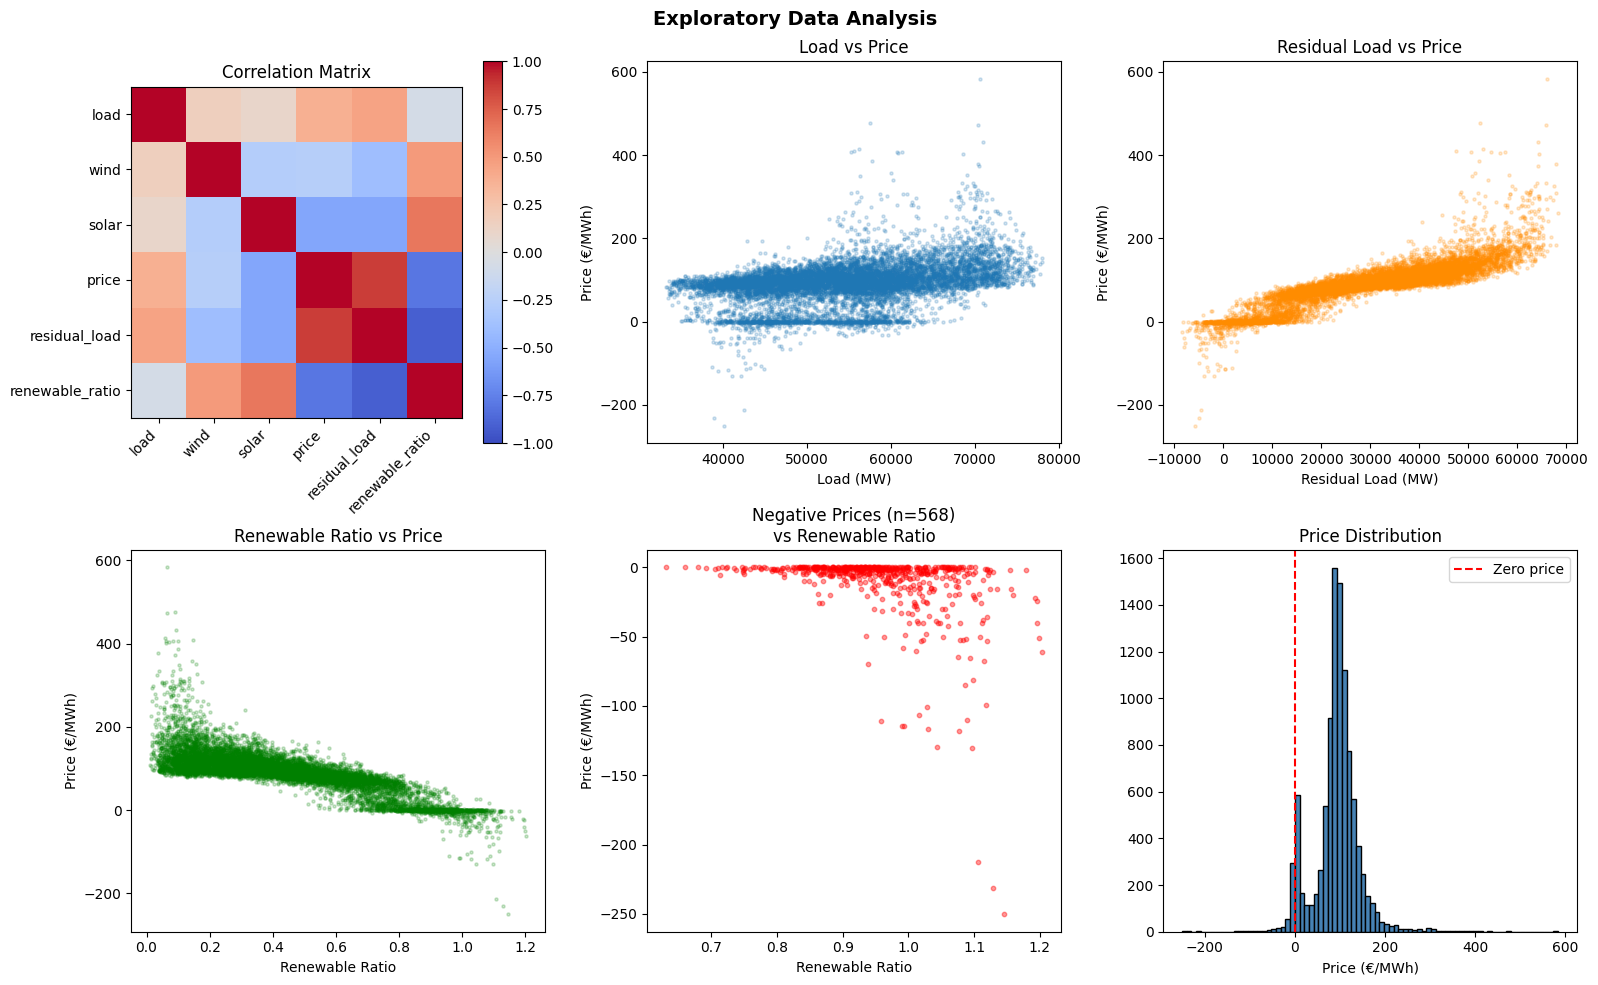

Saved: eda_analysis.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
 
# Correlation heatmap
corr = df[["load","wind","solar","price","residual_load","renewable_ratio"]].corr()
im = axes[0,0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[0,0].set_xticks(range(len(corr.columns)))
axes[0,0].set_yticks(range(len(corr.columns)))
axes[0,0].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[0,0].set_yticklabels(corr.columns)
axes[0,0].set_title("Correlation Matrix")
plt.colorbar(im, ax=axes[0,0])
 
# Load vs Price
axes[0,1].scatter(df["load"], df["price"], alpha=0.2, s=5)
axes[0,1].set_xlabel("Load (MW)")
axes[0,1].set_ylabel("Price (€/MWh)")
axes[0,1].set_title("Load vs Price")
 
# Residual Load vs Price
axes[0,2].scatter(df["residual_load"], df["price"], alpha=0.2, s=5, color="darkorange")
axes[0,2].set_xlabel("Residual Load (MW)")
axes[0,2].set_ylabel("Price (€/MWh)")
axes[0,2].set_title("Residual Load vs Price")
 
# Renewable Ratio vs Price
axes[1,0].scatter(df["renewable_ratio"], df["price"], alpha=0.2, s=5, color="green")
axes[1,0].set_xlabel("Renewable Ratio")
axes[1,0].set_ylabel("Price (€/MWh)")
axes[1,0].set_title("Renewable Ratio vs Price")
 
# Negative pricing analysis
neg_prices = df[df["price"] < 0]
axes[1,1].scatter(neg_prices["renewable_ratio"], neg_prices["price"],
                   alpha=0.4, s=10, color="red")
axes[1,1].set_xlabel("Renewable Ratio")
axes[1,1].set_ylabel("Price (€/MWh)")
axes[1,1].set_title(f"Negative Prices (n={len(neg_prices)})\nvs Renewable Ratio")
 
# Price distribution
axes[1,2].hist(df["price"], bins=80, edgecolor="black", color="steelblue")
axes[1,2].axvline(0, color="red", linestyle="--", label="Zero price")
axes[1,2].set_xlabel("Price (€/MWh)")
axes[1,2].set_title("Price Distribution")
axes[1,2].legend()
 
plt.suptitle("Exploratory Data Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_analysis.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: eda_analysis.png")
 


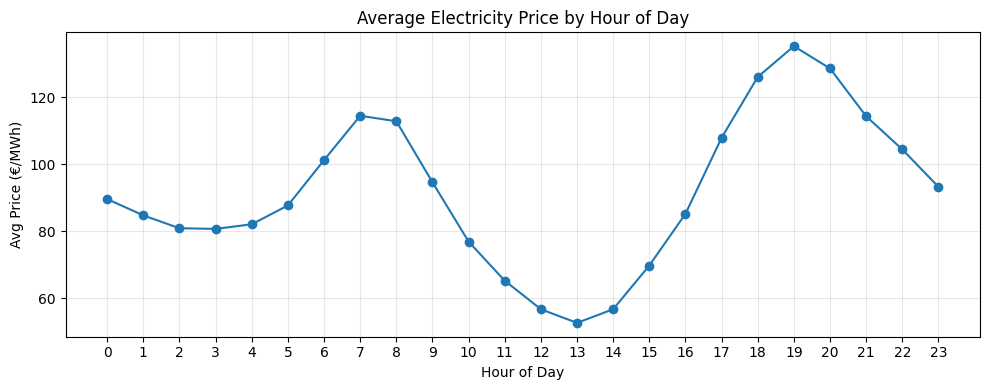

In [5]:
hourly_avg = df.groupby("hour")["price"].mean()
plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Price (€/MWh)")
plt.title("Average Electricity Price by Hour of Day")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hourly_pattern.png", dpi=200)
plt.show()

In [6]:
FEATURES = [
    "load", "wind", "solar",
    "residual_load", "renewable_ratio",
    "price_lag_1", "price_lag_24", "price_lag_168",
    "price_rolling_24", "price_rolling_168",
    "hour_sin", "hour_cos",
    "day_of_week", "month", "is_weekend",
    "price_spike"
]
 
X = df[FEATURES]
y = df["price"]
 
# Strict temporal split — never shuffle time-series data
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
time_test = df["time"].iloc[split_index:]
 
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Test period: {time_test.min()} → {time_test.max()}")


Train size: 8011, Test size: 2003
Test period: 2025-12-07 13:00:00 → 2026-02-28 23:00:00


In [7]:
naive_predictions = X_test["price_lag_1"].values
naive_mae = mean_absolute_error(y_test, naive_predictions)
naive_r2  = r2_score(y_test, naive_predictions)
print(f"\n{'='*45}")
print(f"NAIVE BASELINE (predict = price_lag_1)")
print(f"  MAE: {naive_mae:.3f} €/MWh")
print(f"  R²:  {naive_r2:.4f}")
print(f"{'='*45}")



NAIVE BASELINE (predict = price_lag_1)
  MAE: 6.991 €/MWh
  R²:  0.8874


In [8]:
tscv = TimeSeriesSplit(n_splits=5)
 
cv_results = {"Linear": [], "RandomForest": [], "XGBoost": []}
 
print("\nWalk-Forward Cross Validation...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    Xf_train, Xf_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    yf_train, yf_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
 
    # Linear
    lr = LinearRegression()
    lr.fit(Xf_train, yf_train)
    cv_results["Linear"].append(mean_absolute_error(yf_val, lr.predict(Xf_val)))
 
    # Random Forest (lighter for CV speed)
    rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(Xf_train, yf_train)
    cv_results["RandomForest"].append(mean_absolute_error(yf_val, rf.predict(Xf_val)))
 
    # XGBoost
    xgb = XGBRegressor(n_estimators=100, learning_rate=0.05,
                        max_depth=5, random_state=42, verbosity=0)
    xgb.fit(Xf_train, yf_train)
    cv_results["XGBoost"].append(mean_absolute_error(yf_val, xgb.predict(Xf_val)))
 
    print(f"  Fold {fold+1}: LR={cv_results['Linear'][-1]:.2f} | "
          f"RF={cv_results['RandomForest'][-1]:.2f} | "
          f"XGB={cv_results['XGBoost'][-1]:.2f}")
 
print("\nCV Summary (MAE mean ± std):")
for name, scores in cv_results.items():
    print(f"  {name:15s}: {np.mean(scores):.3f} ± {np.std(scores):.3f}")
 


Walk-Forward Cross Validation...
  Fold 1: LR=12.94 | RF=13.38 | XGB=15.03
  Fold 2: LR=13.25 | RF=10.26 | XGB=10.30
  Fold 3: LR=10.40 | RF=7.94 | XGB=7.33
  Fold 4: LR=13.69 | RF=9.78 | XGB=8.77
  Fold 5: LR=12.61 | RF=13.24 | XGB=10.02

CV Summary (MAE mean ± std):
  Linear         : 12.578 ± 1.146
  RandomForest   : 10.920 ± 2.098
  XGBoost        : 10.290 ± 2.592


In [9]:
print("\nTraining final models on full training set...")
 
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
 
# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
 
# XGBoost (best model)
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_preds = xgb_model.predict(X_test)
 


Training final models on full training set...


In [10]:
results = pd.DataFrame({
    "Model": ["Naive Baseline", "Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [
        round(naive_mae, 2),
        round(mean_absolute_error(y_test, lr_preds), 2),
        round(mean_absolute_error(y_test, rf_preds), 2),
        round(mean_absolute_error(y_test, xgb_preds), 2),
    ],
    "R2": [
        round(naive_r2, 4),
        round(r2_score(y_test, lr_preds), 4),
        round(r2_score(y_test, rf_preds), 4),
        round(r2_score(y_test, xgb_preds), 4),
    ]
})
print("\n", results.to_string(index=False))


             Model  MAE     R2
   Naive Baseline 6.99 0.8874
Linear Regression 9.49 0.8545
    Random Forest 6.84 0.9020
          XGBoost 6.50 0.9179


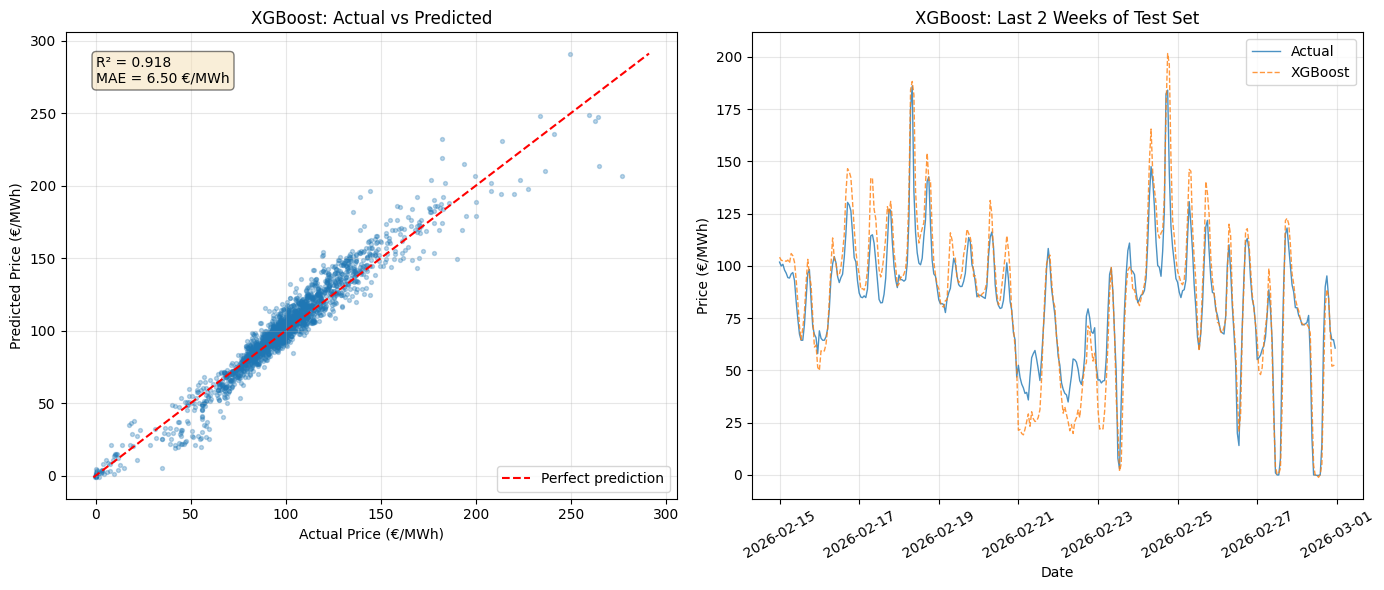

Saved: actual_vs_predicted.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Scatter
axes[0].scatter(y_test, xgb_preds, alpha=0.3, s=8)
lims = [min(y_test.min(), xgb_preds.min()), max(y_test.max(), xgb_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Price (€/MWh)")
axes[0].set_ylabel("Predicted Price (€/MWh)")
axes[0].set_title("XGBoost: Actual vs Predicted")
axes[0].text(0.05, 0.95,
             f"R² = {r2_score(y_test, xgb_preds):.3f}\nMAE = {mean_absolute_error(y_test, xgb_preds):.2f} €/MWh",
             transform=axes[0].transAxes, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
axes[0].legend()
axes[0].grid(alpha=0.3)
 
# Time series: last 2 weeks of test set for clarity
n_show = min(336, len(y_test))  # 2 weeks of hourly data
axes[1].plot(time_test.values[-n_show:], y_test.values[-n_show:],
             label="Actual", alpha=0.8, linewidth=1)
axes[1].plot(time_test.values[-n_show:], xgb_preds[-n_show:],
             label="XGBoost", alpha=0.8, linewidth=1, linestyle="--")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Price (€/MWh)")
axes[1].set_title("XGBoost: Last 2 Weeks of Test Set")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: actual_vs_predicted.png")

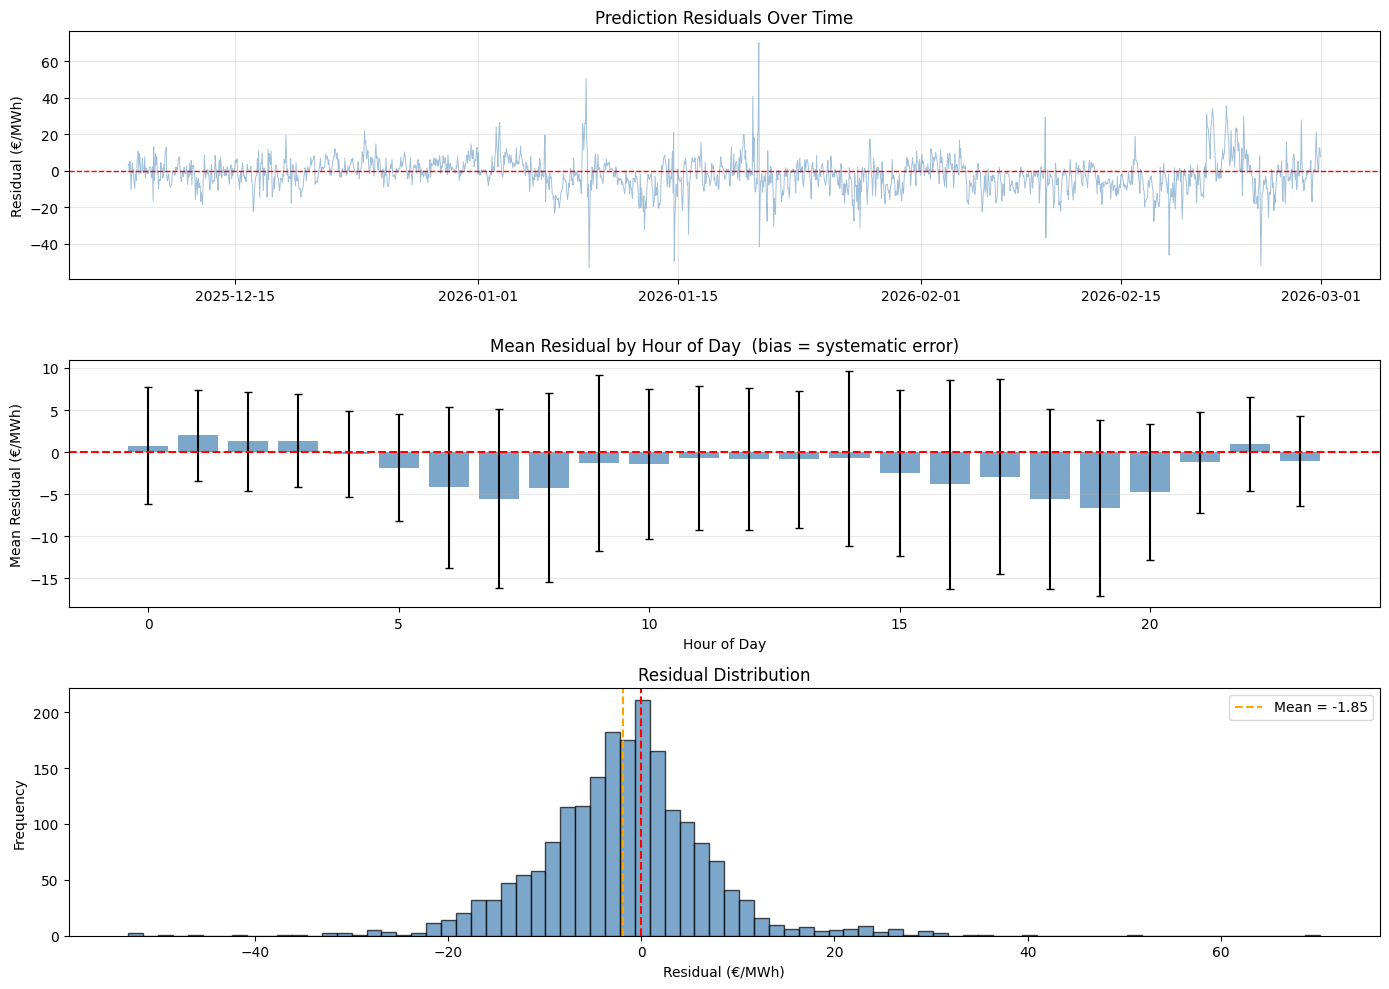

Saved: residual_analysis.png


In [ ]:
residuals = y_test.values - xgb_preds
 
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
 
# Residuals over time
axes[0].plot(time_test.values, residuals, alpha=0.5, linewidth=0.7, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_ylabel("Residual (€/MWh)")
axes[0].set_title("Prediction Residuals Over Time")
axes[0].grid(alpha=0.3)
 
# Residuals by hour of day
residual_df = pd.DataFrame({
    "residual": residuals,
    "hour": df["hour"].iloc[split_index:].values,
    "day_of_week": df["day_of_week"].iloc[split_index:].values
})
hourly_res = residual_df.groupby("hour")["residual"].agg(["mean", "std"]).reset_index()
axes[1].bar(hourly_res["hour"], hourly_res["mean"],
            yerr=hourly_res["std"], capsize=3, color="steelblue", alpha=0.7)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Mean Residual (€/MWh)")
axes[1].set_title("Mean Residual by Hour of Day  (bias = systematic error)")
axes[1].grid(alpha=0.3, axis="y")
 
# Residual distribution
axes[2].hist(residuals, bins=80, edgecolor="black", color="steelblue", alpha=0.7)
axes[2].axvline(0, color="red", linestyle="--")
axes[2].axvline(np.mean(residuals), color="orange", linestyle="--",
                label=f"Mean = {np.mean(residuals):.2f}")
axes[2].set_xlabel("Residual (€/MWh)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Residual Distribution")
axes[2].legend()
 
plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: residual_analysis.png")

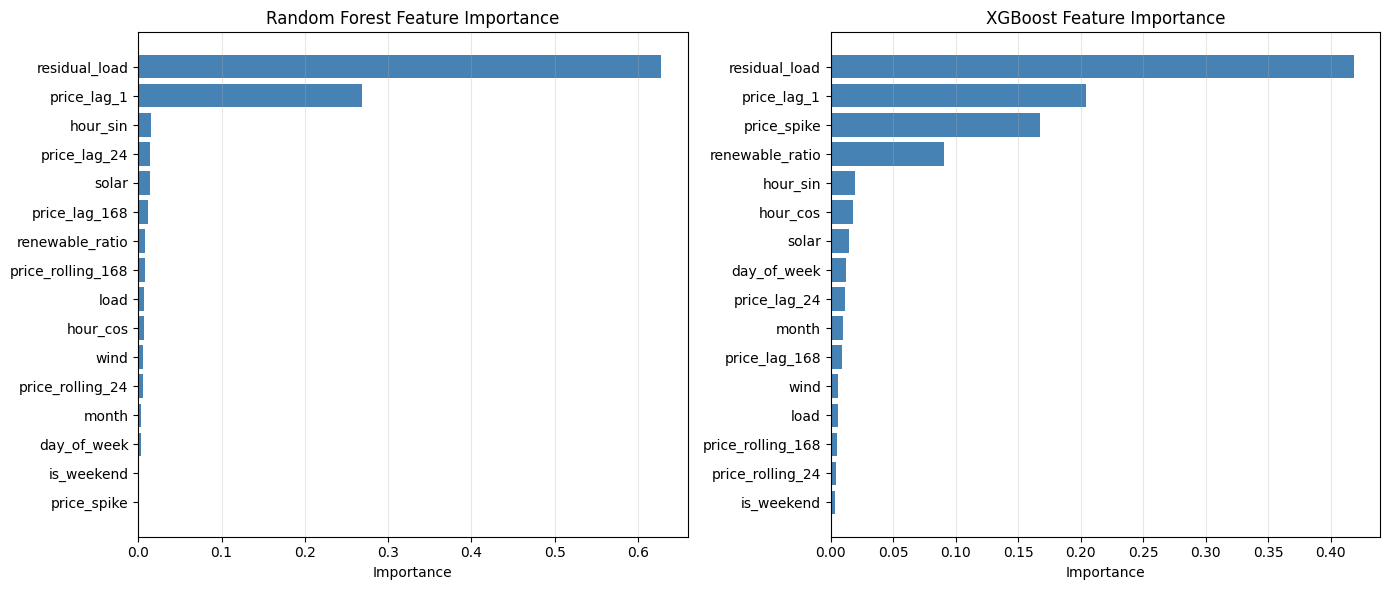

Saved: feature_importance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
for ax, model, name in [(axes[0], rf_model, "Random Forest"),
                         (axes[1], xgb_model, "XGBoost")]:
    imp = pd.DataFrame({
        "Feature": FEATURES,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=True)
 
    ax.barh(imp["Feature"], imp["Importance"], color="steelblue")
    ax.set_xlabel("Importance")
    ax.set_title(f"{name} Feature Importance")
    ax.grid(alpha=0.3, axis="x")
 
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")


Generating SHAP values (this may take ~30s)...


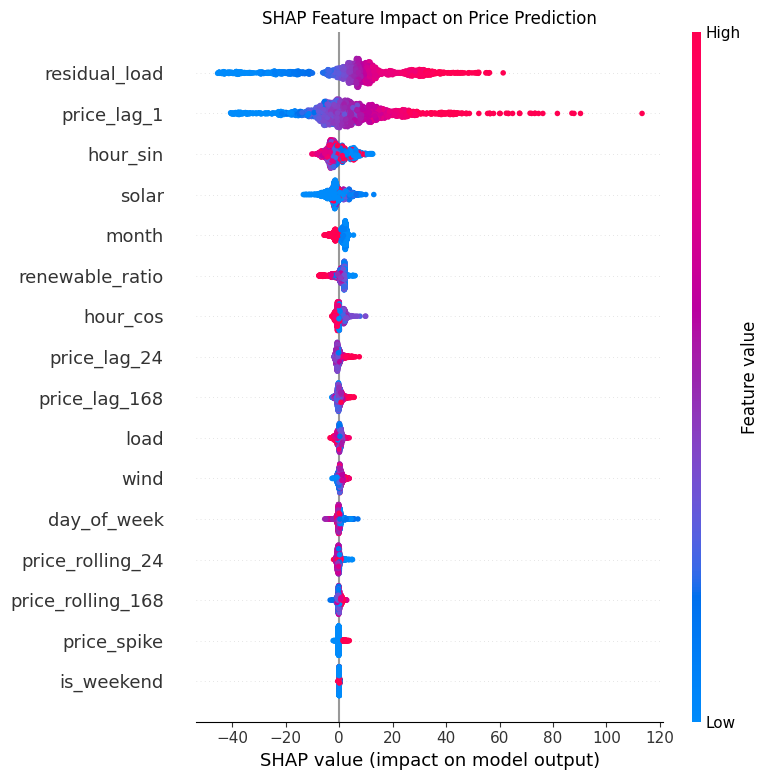

Saved: shap_summary.png


In [ ]:
print("\nGenerating SHAP values (this may take ~30s)...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
 
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Impact on Price Prediction")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: shap_summary.png")

In [12]:
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(results.to_string(index=False))
print(f"\nModels beating naive baseline (MAE < {naive_mae:.2f}):")
for _, row in results.iterrows():
    if row["Model"] != "Naive Baseline":
        beat = "✅ Beats baseline" if row["MAE"] < naive_mae else "❌ Does not beat baseline"
        print(f"  {row['Model']:20s}: MAE={row['MAE']:.2f}  {beat}")
 
print("\nKey Insights:")
print("  - price_lag_1 dominates → market has strong mean-reversion/inertia")
print("  - Renewable generation (wind/solar) drives negative and low prices")
print("  - Residual load is a cleaner price signal than raw load")
print("  - Hourly and seasonal patterns captured via cyclical encoding")



FINAL RESULTS SUMMARY
            Model  MAE     R2
   Naive Baseline 6.99 0.8874
Linear Regression 9.49 0.8545
    Random Forest 6.84 0.9020
          XGBoost 6.50 0.9179

Models beating naive baseline (MAE < 6.99):
  Linear Regression   : MAE=9.49  ❌ Does not beat baseline
  Random Forest       : MAE=6.84  ✅ Beats baseline
  XGBoost             : MAE=6.50  ✅ Beats baseline

Key Insights:
  - price_lag_1 dominates → market has strong mean-reversion/inertia
  - Renewable generation (wind/solar) drives negative and low prices
  - Residual load is a cleaner price signal than raw load
  - Hourly and seasonal patterns captured via cyclical encoding
